# PENGWIN · 03 — Modelado del detector anatómico

Construcción y validación paso a paso de un detector *anchor-free* para las tres regiones anatómicas de la pelvis (**sacro**, **coxal izquierdo** y **coxal derecho**) sobre imágenes 2.5D de 256×256.

**Arquitectura objetivo**

```
Imagen [B, 3, 256, 256]
   ↓
FundidoraPCBackbone  →  [B, 256, 32, 32]   (out_stride = 8)
   ↓
CBAM
   ├── Detection Head        →  objectness + bbox      (implementada)
   ├── Classification Head                              (pendiente)
   └── Segmentation Head                                (pendiente)
```

**Contenido**

1. Configuración
2. Datos: dataset, DataLoader y auditoría de las cajas
3. Arquitectura: backbone, CBAM, cabeza de detección y detector integrado
4. Objetivos de detección y pérdida
5. Validación del aprendizaje: gradientes y mini-overfit
6. Postprocesamiento: decodificación, umbral y NMS
7. Estado actual y pendientes

Conviene ejecutar el notebook de arriba hacia abajo: varias celdas reutilizan variables de las anteriores (`images`, `targets`, `model`, `outputs`).

## 1. Configuración

Rutas del proyecto e importaciones. Se agrega `03_src` al `sys.path` para poder importar el paquete propio `pengwin`.

In [1]:
# Rutas del proyecto e importaciones generales.
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as patches

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "03_src"
DATA_DIR = PROJECT_ROOT / "01_data"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("===== RUTAS =====")
print("Proyecto:", PROJECT_ROOT)
print("Código fuente:", SRC_DIR)
print("Datos:", DATA_DIR)

===== RUTAS =====
Proyecto: d:\Analitica de Datos\Analitica-de-datos-Proyecto-2-PENGWIN
Código fuente: d:\Analitica de Datos\Analitica-de-datos-Proyecto-2-PENGWIN\03_src
Datos: d:\Analitica de Datos\Analitica-de-datos-Proyecto-2-PENGWIN\01_data


In [2]:
# Componentes propios del proyecto: datos, modelo, targets y pérdida.

# --- Datos ---
from pengwin.data.dataset import PENGWINDataset
from pengwin.data.data_loader import load_and_standardize_mha
from pengwin.data.preprocessing import compute_bone_crop, transform_boxes_to_crop

# --- Modelo ---
from pengwin.models.backbone import FundidoraPCBackbone
from pengwin.models.cbam import ChannelAttention, SpatialAttention, CBAM
from pengwin.models.detection import DetectionHead
from pengwin.models.detector import PENGWINDetector

# --- Targets y pérdida ---
from pengwin.models.targets import build_detection_targets
from pengwin.models.detection_loss import detection_loss

## 2. Datos

Cada elemento de `PENGWINDataset` es `(image, target)`:

- `image`: imagen 2.5D de 3 canales, `[3, 256, 256]`.
- `target`: diccionario con `boxes` y `labels` (las tres regiones anatómicas: 0 = sacro, 1 = coxal izquierdo, 2 = coxal derecho), `mask` (máscara con los IDs originales de los fragmentos), `case_id` y `z` (slice usada).

### 2.1 Dataset

In [3]:
# Creación del dataset (imágenes 2.5D de 256×256; ventana HU: centro 400, ancho 1800).
dataset = PENGWINDataset(
    data_dir=DATA_DIR,
    output_size=256,
    context_mm=2.0,
    crop_margin_mm=15.0,
    window_center=400,
    window_width=1800,
)

print("Número de casos:", len(dataset))

Número de casos: 100


### 2.2 DataLoader

El *collate* apila las imágenes y deja los targets como lista. El DataLoader usa batch de 4 y `shuffle=False`, de modo que el primer batch es siempre el mismo; las pruebas posteriores (forward, gradientes y mini-overfit) vuelven a pedirlo con `next(iter(loader))`.

In [4]:
# Collate personalizado: imágenes apiladas en un tensor, targets como lista.
def detection_collate_fn(batch):
    images = []
    targets = []

    for image, target in batch:
        images.append(image)
        targets.append(target)

    images = torch.stack(images, dim=0)

    return images, targets

In [5]:
# DataLoader sin mezclar, para que el primer batch sea reproducible.
loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    collate_fn=detection_collate_fn,
)

### 2.3 Verificación de un batch

Se espera una imagen `[4, 3, 256, 256]` y 4 targets, uno por imagen.

In [6]:
# Verificación de dimensiones y estructura de un batch.
images, targets = next(iter(loader))

print("Images:", images.shape)
print("Targets:", len(targets))

Images: torch.Size([4, 3, 256, 256])
Targets: 4


### 2.4 Inspección de una muestra

Validaciones automáticas (formas, cajas dentro de la imagen, orden de las coordenadas, clases en {0, 1, 2}) y visualización del canal central, las cajas y la máscara de fragmentos.

Caso: 001
Corte: 216

Dimensiones:
Imagen: torch.Size([3, 256, 256])
Cajas: torch.Size([3, 4])
Clases: torch.Size([3])
Máscara: torch.Size([256, 256])

Clases detectadas:
[0, 1, 2]

Cajas:
tensor([[107.9267, 166.3218, 147.0306, 179.3564],
        [167.8860,  86.0285, 206.9898, 133.9959],
        [ 55.7882,  81.3361,  87.5927, 132.4318]])

IDs presentes en la máscara:
[0, 1, 11, 21]

Todas las validaciones básicas fueron superadas.


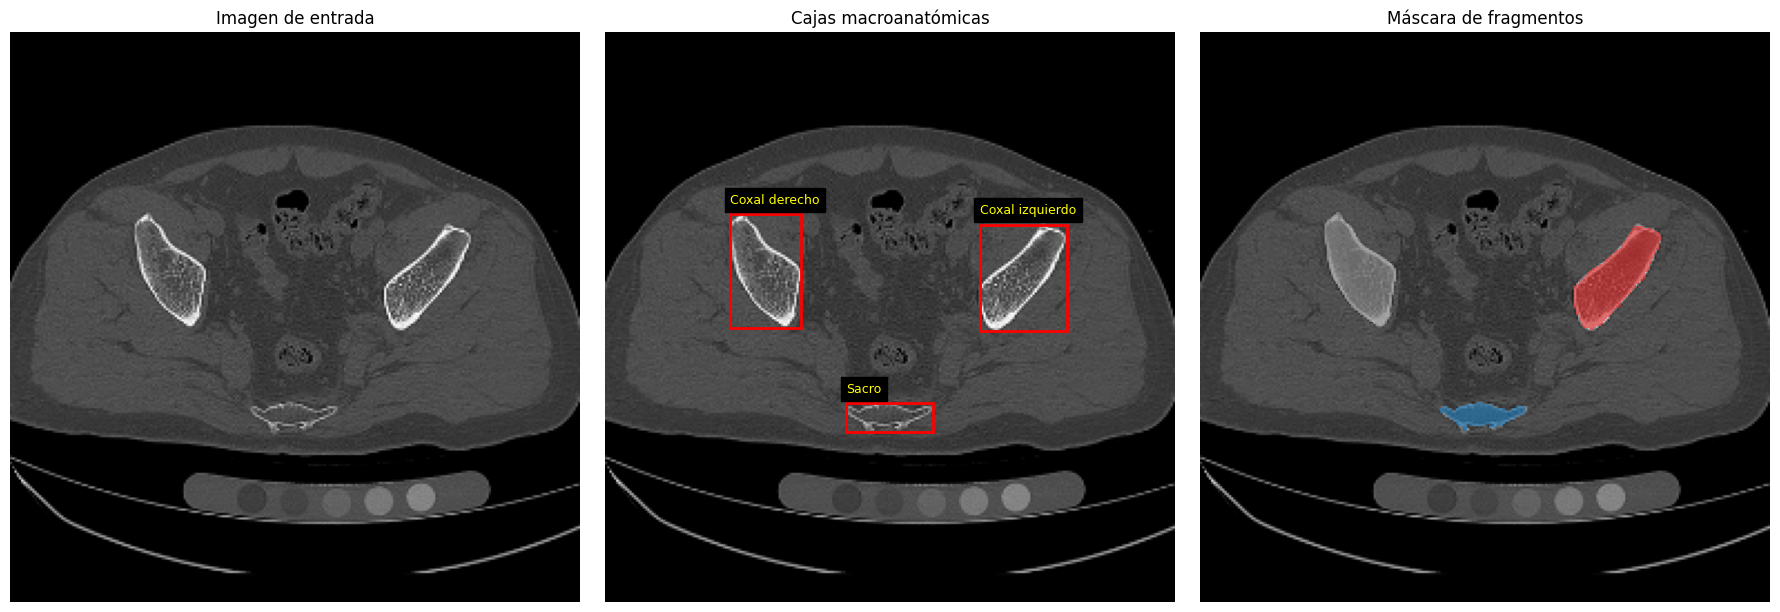

In [7]:
# Inspección de una muestra: validaciones automáticas y visualización (imagen, cajas y máscara).
# ================================================
# 1. Obtener una muestra
# ================================================

image, target = dataset[0]

print("Caso:", target["case_id"])
print("Corte:", target["z"])

print("\nDimensiones:")
print("Imagen:", image.shape)
print("Cajas:", target["boxes"].shape)
print("Clases:", target["labels"].shape)
print("Máscara:", target["mask"].shape)

print("\nClases detectadas:")
print(target["labels"].tolist())

print("\nCajas:")
print(target["boxes"])

print("\nIDs presentes en la máscara:")
print(torch.unique(target["mask"]).tolist())

# ================================================
# 2. Validaciones automáticas
# ================================================

assert image.shape == (3, 256, 256)
assert target["boxes"].ndim == 2
assert target["boxes"].shape[1] == 4
assert target["labels"].shape[0] == target["boxes"].shape[0]
assert target["mask"].shape == (256, 256)

assert torch.all(target["boxes"][:, 0] < target["boxes"][:, 2])
assert torch.all(target["boxes"][:, 1] < target["boxes"][:, 3])

assert torch.all(target["boxes"] >= 0)
assert torch.all(target["boxes"] <= 256)

assert set(target["labels"].tolist()).issubset({0, 1, 2})

print("\nTodas las validaciones básicas fueron superadas.")

# ================================================
# 3. Preparar imagen para visualizar
# ================================================

image_np = image.numpy()

# Canal central: corte z
central_slice = image_np[1]

mask_np = target["mask"].numpy()
boxes_np = target["boxes"].numpy()
labels_np = target["labels"].numpy()

class_names = {
    0: "Sacro",
    1: "Coxal izquierdo",
    2: "Coxal derecho",
}

# ================================================
# 4. Visualización
# ================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Imagen original
axes[0].imshow(central_slice, cmap="gray")
axes[0].set_title("Imagen de entrada")
axes[0].axis("off")

# Imagen con cajas
axes[1].imshow(central_slice, cmap="gray")

for box, label in zip(boxes_np, labels_np):
    x1, y1, x2, y2 = box

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )

    axes[1].add_patch(rect)

    axes[1].text(
        x1,
        max(0, y1 - 5),
        class_names[int(label)],
        color="yellow",
        fontsize=9,
        backgroundcolor="black",
    )

axes[1].set_title("Cajas macroanatómicas")
axes[1].axis("off")

# Máscara de fragmentos
axes[2].imshow(central_slice, cmap="gray")
axes[2].imshow(
    np.ma.masked_where(mask_np == 0, mask_np),
    alpha=0.65,
    cmap="tab10",
    interpolation="nearest",
    vmin=0,
    vmax=30,
)
axes[2].set_title("Máscara de fragmentos")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 2.5 Auditoría de las cajas anatómicas

Antes de construir los targets se comprueba que las cajas del dataset son correctas y compatibles con la cuadrícula 32×32 del detector, en cuatro pasos:

1. Estadísticas de las cajas que entrega el dataset.
2. Reconstrucción manual de las cajas desde las etiquetas originales (caso de ejemplo).
3. Función de reconstrucción general aplicada a los 100 casos, como comprobación cruzada del dataset.
4. Ocupación de la cuadrícula y colisiones de centros.

#### 2.5.1 Estadísticas de las cajas del dataset

Recorre los 100 casos: 300 cajas en total, exactamente 3 por imagen y 100 por clase.

In [8]:
# Estadísticas de las cajas que entrega el dataset (recorre los 100 casos).
rows = []

for idx in range(len(dataset)):
    image, target = dataset[idx]

    boxes = target["boxes"].numpy()
    labels = target["labels"].numpy()

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box

        w = x2 - x1
        h = y2 - y1
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        rows.append({
            "dataset_idx": idx,
            "class": int(label),
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "cx": cx,
            "cy": cy,
            "width": w,
            "height": h,
            "area": w * h,
            "aspect_ratio": w / h,
        })

boxes_df = pd.DataFrame(rows)

print("Imágenes analizadas:", len(dataset))
print("Total de cajas:", len(boxes_df))
print("Cajas por imagen:")
print(
    boxes_df.groupby("dataset_idx")
    .size()
    .value_counts()
    .sort_index()
)

print("\nResumen de cajas:")
display(
    boxes_df[
        ["width", "height", "area", "aspect_ratio", "cx", "cy"]
    ].describe()
)

print("\nCajas por clase:")
display(
    boxes_df["class"]
    .value_counts()
    .sort_index()
)

Imágenes analizadas: 100
Total de cajas: 300
Cajas por imagen:
3    100
Name: count, dtype: int64

Resumen de cajas:


,width,height,area,aspect_ratio,cx,cy
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,43.099964,45.015339,1833.022339,1.435193,126.616302,135.030624
std,12.596913,20.389036,918.609314,1.187457,53.903713,31.197815
min,14.706390,6.384048,97.814484,0.384615,43.224400,80.979599
25%,32.898315,23.243496,1220.503204,0.590057,66.364071,110.209625
50%,40.179829,51.319607,1732.528564,0.737564,127.222870,118.819832
75%,52.588234,58.148138,2154.702576,2.580357,187.265892,173.487091
max,79.286087,99.002289,6552.650879,5.500002,208.115112,197.494202



Cajas por clase:


class
0    100
1    100
2    100
Name: count, dtype: int64

#### 2.5.2 Reconstrucción manual de un caso

Se repite paso a paso lo que hace el dataset para el caso de referencia: etiquetas originales → caja por región en la slice central → recorte óseo → transformación a 256×256.

Como todas las imágenes tienen 3 cajas, `idxmax` devuelve el primer caso (índice 0, caso 001).

In [9]:
# Caso de referencia: la imagen con más cajas (todas tienen 3, así que resulta el índice 0).
idx = boxes_df.groupby("dataset_idx").size().idxmax()

image, target = dataset[idx]

print("Índice:", idx)
print("Número de cajas:", len(target["boxes"]))
print("Clases:", target["labels"].tolist())
print("\nBoxes:")
print(target["boxes"].numpy())

Índice: 0
Número de cajas: 3
Clases: [0, 1, 2]

Boxes:
[[107.92669  166.32181  147.03056  179.35643 ]
 [167.88596   86.02852  206.98982  133.99593 ]
 [ 55.78819   81.33605   87.592674 132.43178 ]]


In [10]:
# Etiquetas originales del caso de referencia: IDs de fragmentos presentes en el volumen.
sample = dataset.pairs[idx]

print("Caso:", sample["case_id"])
print("Imagen:", sample["image_path"])
print("Label:", sample["label_path"])

label_arr, spacing, orientation = load_and_standardize_mha(
    sample["label_path"]
)

print("Shape:", label_arr.shape)
print("IDs presentes en todo el volumen:")
print(np.unique(label_arr))

Caso: 001
Imagen: d:\Analitica de Datos\Analitica-de-datos-Proyecto-2-PENGWIN\01_data\PENGWIN_CT_train_images_part1\001.mha
Label: d:\Analitica de Datos\Analitica-de-datos-Proyecto-2-PENGWIN\01_data\PENGWIN_CT_train_labels\001.mha
Shape: (401, 512, 512)
IDs presentes en todo el volumen:
[ 0.  1. 11. 12. 21.]


In [11]:
# Slice central entre las slices etiquetadas (la misma que usa el dataset).
labeled_z = np.where(
    np.any(label_arr > 0, axis=(1, 2))
)[0]

z = labeled_z[len(labeled_z) // 2]

print("Slices con etiquetas:", len(labeled_z))
print("Primera slice:", labeled_z[0])
print("Última slice:", labeled_z[-1])
print("Slice seleccionada:", z)

ids_slice = np.unique(label_arr[z])
print("IDs presentes en z =", z, ":", ids_slice)

Slices con etiquetas: 291
Primera slice: 71
Última slice: 361
Slice seleccionada: 216
IDs presentes en z = 216 : [ 0.  1. 11. 21.]


In [12]:
# Caja de cada región en la slice seleccionada.
# Nota: es una exploración puntual; para el sacro solo se usan los IDs 1-4.
# La función general (get_macro_boxes_for_sample, más abajo) usa los IDs 1-10.
def bbox_region(label_slice, ids):
    mask = np.isin(label_slice, ids)

    ys, xs = np.where(mask)

    if len(xs) == 0:
        return None

    return np.array([
        xs.min(),
        ys.min(),
        xs.max() + 1,
        ys.max() + 1
    ], dtype=np.float32)


label_slice = label_arr[z]

bbox_sacro = bbox_region(label_slice, [1, 2, 3, 4])
bbox_coxal_izq = bbox_region(label_slice, list(range(11, 21)))
bbox_coxal_der = bbox_region(label_slice, list(range(21, 31)))

print("Sacro:           ", bbox_sacro)
print("Coxal izquierdo: ", bbox_coxal_izq)
print("Coxal derecho:   ", bbox_coxal_der)

Sacro:            [223. 364. 298. 389.]
Coxal izquierdo:  [338. 210. 413. 302.]
Coxal derecho:    [123. 201. 184. 299.]


In [13]:
# Recorte óseo del volumen (mismo cálculo que usa el dataset).
image_arr, spacing, orientation = load_and_standardize_mha(
    sample["image_path"]
)

crop = compute_bone_crop(
    image_arr,
    spacing,
    margin_mm=15.0,
    bone_threshold_hu=250,
)

print("Crop:")
print("y0:", crop.y0)
print("y1:", crop.y1)
print("x0:", crop.x0)
print("x1:", crop.x1)
print("side_px:", crop.side_px)

Crop:
y0: 45
y1: 536
x0: 16
x1: 507
side_px: 491


In [14]:
# OJO: estas cajas están escritas a mano y no corresponden al caso 001 de las celdas
# anteriores; solo ejercitan transform_boxes_to_crop. Para reproducir el flujo del caso 001
# habría que pasarle las cajas calculadas en la celda de bbox_region.
boxes_original = np.array([
    [154., 189., 252., 214.],  # sacro
    [285.,  77., 329., 156.],  # coxal izquierdo
    [ 80.,  63., 125., 138.],  # coxal derecho
], dtype=np.float32)

boxes_256 = transform_boxes_to_crop(
    boxes_original,
    crop,
    output_size=256
)

print("Cajas en 256x256:")
print(boxes_256)

print("\nAncho x alto:")
for nombre, box in zip(
    ["Sacro", "Coxal izquierdo", "Coxal derecho"],
    boxes_256
):
    w = box[2] - box[0]
    h = box[3] - box[1]
    cx = (box[0] + box[2]) / 2
    cy = (box[1] + box[3]) / 2

    print(
        f"{nombre:18s} "
        f"w={w:.2f}, h={h:.2f}, "
        f"cx={cx:.2f}, cy={cy:.2f}"
    )

Cajas en 256x256:
[[ 71.951126  75.07944  123.04685   88.11406 ]
 [140.25255   16.684319 163.1935    57.87373 ]
 [ 33.368637   9.38493   56.83096   48.4888  ]]

Ancho x alto:
Sacro              w=51.10, h=13.03, cx=97.50, cy=81.60
Coxal izquierdo    w=22.94, h=41.19, cx=151.72, cy=37.28
Coxal derecho      w=23.46, h=39.10, cx=45.10, cy=28.94


In [15]:
# Cajas que entrega el dataset para el mismo caso (comparar con la reconstrucción siguiente).
image, target = dataset[idx]

print("Imagen:", image.shape)
print("Cajas actuales:")
print(target["boxes"])
print("Clases actuales:")
print(target["labels"])

Imagen: torch.Size([3, 256, 256])
Cajas actuales:
tensor([[107.9267, 166.3218, 147.0306, 179.3564],
        [167.8860,  86.0285, 206.9898, 133.9959],
        [ 55.7882,  81.3361,  87.5927, 132.4318]])
Clases actuales:
tensor([0, 1, 2])


#### 2.5.3 Función de reconstrucción y estadísticas globales

`get_macro_boxes_for_sample` repite ese flujo de forma independiente del dataset, con los IDs de fragmento 1–10 (sacro), 11–20 (coxal izquierdo) y 21–30 (coxal derecho). En el caso de referencia da las mismas cajas que el dataset, y sus estadísticas sobre los 100 casos coinciden con las de 2.5.1: es una comprobación cruzada de que el dataset construye bien las cajas.

In [16]:
# Reconstruye las cajas macroanatómicas desde las etiquetas originales, sin pasar por el dataset.
def get_macro_boxes_for_sample(dataset, index):
    case = dataset.pairs[index]

    image, spacing, orientation = load_and_standardize_mha(
        case["image_path"]
    )

    label, _, _ = load_and_standardize_mha(
        case["label_path"]
    )

    bone_crop = compute_bone_crop(
        volume_hu=image,
        spacing_zyx=spacing,
        margin_mm=dataset.crop_margin_mm,
    )

    slices_with_labels = np.where(
        np.any(label > 0, axis=(1, 2))
    )[0]

    z = slices_with_labels[len(slices_with_labels) // 2]

    label_slice = label[z]

    region_ids = {
        0: range(1, 11),    # sacro
        1: range(11, 21),   # coxal izquierdo
        2: range(21, 31),   # coxal derecho
    }

    boxes_original = []
    classes = []

    for class_idx, valid_ids in region_ids.items():

        mask = np.isin(
            label_slice,
            list(valid_ids)
        )

        ys, xs = np.where(mask)

        if len(xs) == 0:
            continue

        boxes_original.append([
            xs.min(),
            ys.min(),
            xs.max() + 1,
            ys.max() + 1,
        ])

        classes.append(class_idx)

    boxes_original = np.asarray(
        boxes_original,
        dtype=np.float32
    )

    boxes = transform_boxes_to_crop(
        boxes_original,
        bone_crop,
        output_size=dataset.output_size,
    )

    return {
        "case_id": case["case_id"],
        "z": z,
        "boxes": boxes,
        "classes": np.asarray(classes),
    }

In [17]:
# Prueba de la reconstrucción en el caso de referencia.
macro = get_macro_boxes_for_sample(dataset, idx)

print("Caso:", macro["case_id"])
print("z:", macro["z"])
print("Boxes:")
print(macro["boxes"])
print("Clases:")
print(macro["classes"])

Caso: 001
z: 216
Boxes:
[[107.92669  166.32181  147.03056  179.35643 ]
 [167.88596   86.02852  206.98982  133.99593 ]
 [ 55.78819   81.33605   87.592674 132.43178 ]]
Clases:
[0 1 2]


In [18]:
# Todas las cajas reconstruidas, con su celda (grid_x, grid_y) en la cuadrícula 32×32 (stride 8).
rows = []

for i in range(len(dataset)):

    sample = get_macro_boxes_for_sample(dataset, i)

    for box, cls in zip(
        sample["boxes"],
        sample["classes"]
    ):

        x1, y1, x2, y2 = box

        w = x2 - x1
        h = y2 - y1

        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        # Celda correspondiente en un grid 32x32
        gx = int(np.floor(cx / 8))
        gy = int(np.floor(cy / 8))

        rows.append({
            "dataset_idx": i,
            "case_id": sample["case_id"],
            "z": sample["z"],
            "class": int(cls),
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "width": w,
            "height": h,
            "area": w * h,
            "aspect_ratio": w / h,
            "cx": cx,
            "cy": cy,
            "grid_x": gx,
            "grid_y": gy,
        })

macro_df = pd.DataFrame(rows)

print("Total de cajas:", len(macro_df))
print("Imágenes:", macro_df["dataset_idx"].nunique())

print("\nCajas por imagen:")
print(
    macro_df
    .groupby("dataset_idx")
    .size()
    .value_counts()
    .sort_index()
)

print("\nResumen geométrico:")
print(
    macro_df[
        ["width", "height", "area", "aspect_ratio", "cx", "cy"]
    ].describe()
)

print("\nCajas por clase:")
print(
    macro_df["class"]
    .value_counts()
    .sort_index()
)

Total de cajas: 300
Imágenes: 100

Cajas por imagen:
3    100
Name: count, dtype: int64

Resumen geométrico:
            width      height         area  aspect_ratio          cx  \
count  300.000000  300.000000   300.000000    300.000000  300.000000   
mean    43.099964   45.015339  1833.022339      1.435193  126.616302   
std     12.596913   20.389036   918.609314      1.187457   53.903713   
min     14.706390    6.384048    97.814484      0.384615   43.224400   
25%     32.898315   23.243496  1220.503204      0.590057   66.364071   
50%     40.179829   51.319607  1732.528564      0.737564  127.222870   
75%     52.588234   58.148138  2154.702576      2.580357  187.265892   
max     79.286087   99.002289  6552.650879      5.500002  208.115112   

               cy  
count  300.000000  
mean   135.030624  
std     31.197815  
min     80.979599  
25%    110.209625  
50%    118.819832  
75%    173.487091  
max    197.494202  

Cajas por clase:
class
0    100
1    100
2    100
Name: count

#### 2.5.4 Cuadrícula 32×32: ocupación y colisiones

Con stride 8, el centro de cada caja cae en una celda, y cada objeto marca una única celda positiva. Por eso importa que dos objetos de la misma imagen no compartan celda.

- La primera celda acumula los 100 casos. Que haya celdas con varios objetos (hasta 23) **no** es un problema, porque son imágenes distintas; solo muestra que los centros se concentran en pocas celdas (300 cajas en 69 celdas).
- La segunda celda cuenta las colisiones reales (mismo caso, misma celda): hay 0, así que asignar un objeto por celda es seguro en este dataset.

In [19]:
# Ocupación de la cuadrícula acumulando los 100 casos (conteos > 1 NO son colisiones: son casos distintos).
grid_counts = (
    macro_df
    .groupby(["grid_x", "grid_y"])
    .size()
    .reset_index(name="n")
)

print("Número de celdas ocupadas:", len(grid_counts))

print("\nDistribución de objetos por celda:")
print(
    grid_counts["n"]
    .value_counts()
    .sort_index()
)

print("\nMáximo de objetos en una misma celda:")
print(grid_counts["n"].max())

Número de celdas ocupadas: 69

Distribución de objetos por celda:
n
1     26
2     12
3      5
4      5
5      6
6      1
8      3
9      1
11     3
12     1
13     1
14     1
16     1
17     1
18     1
23     1
Name: count, dtype: int64

Máximo de objetos en una misma celda:
23


In [20]:
# Colisiones reales: objetos del MISMO caso cuyo centro cae en la misma celda.
collisions = (
    macro_df
    .groupby(["dataset_idx", "grid_x", "grid_y"])
    .agg(
        n=("class", "size"),
        classes=("class", lambda x: sorted(x.tolist()))
    )
    .reset_index()
)

collisions = collisions[collisions["n"] > 1]

print("Colisiones:", len(collisions))

if len(collisions) > 0:
    print(collisions.to_string(index=False))
else:
    print("No existen colisiones de centros.")

Colisiones: 0
No existen colisiones de centros.


#### 2.5.5 Estadísticas por clase

Los sacros son cajas alargadas en horizontal (relación de aspecto media ≈ 3.0) y los coxales son cajas verticales (≈ 0.6–0.7).

In [21]:
# Estadísticas geométricas por clase.
class_names = {
    0: "Sacro",
    1: "Coxal izquierdo",
    2: "Coxal derecho",
}

for cls, name in class_names.items():

    df_cls = macro_df[macro_df["class"] == cls]

    print(f"\n===== {name} =====")

    print(
        df_cls[
            ["width", "height", "area", "aspect_ratio"]
        ].describe()
    )


===== Sacro =====
            width      height         area  aspect_ratio
count  100.000000  100.000000   100.000000    100.000000
mean    54.452637   19.375370  1099.929199      2.993163
std     10.377557    6.915432   550.870605      0.726499
min     14.706390    6.384048    97.814484      1.276596
25%     49.011963   14.774105   721.394318      2.598214
50%     55.144070   18.306175   985.522644      2.984374
75%     61.389143   23.185017  1350.693329      3.440000
max     73.834518   49.908264  3516.472168      5.500002

===== Coxal izquierdo =====
            width      height         area  aspect_ratio
count  100.000000  100.000000   100.000000    100.000000
mean    36.365948   57.862118  2145.389648      0.636176
std      8.622720   10.432260   839.705322      0.144698
min     23.333328   42.134666  1078.183472      0.400000
25%     30.432144   51.263123  1649.702942      0.529101
50%     34.094978   56.377308  1896.624756      0.606673
75%     39.542744   60.070595  2323.0104

## 3. Arquitectura del detector

El detector se arma por etapas, validando las formas en cada una: backbone → CBAM → cabeza de detección → modelo integrado. El README exige que CBAM esté antes de las tres cabezas.

### 3.1 Backbone FundidoraPC

Cuatro bloques convolucionales que mantienen el mapa espacial en 32×32 (`out_stride = 8`): `[4, 3, 256, 256]` → `[4, 256, 32, 32]`.

In [22]:
# Construcción y validación del backbone basado en FundidoraPC.
backbone = FundidoraPCBackbone()

features = backbone(images)

print("Entrada:", images.shape)
print("Salida:", features.shape)
print("out_features:", backbone.out_features)
print("out_stride:", backbone.out_stride)

Entrada: torch.Size([4, 3, 256, 256])
Salida: torch.Size([4, 256, 32, 32])
out_features: 256
out_stride: 8


### 3.2 CBAM

Dos etapas en serie, atención de canal y atención espacial; ambas conservan la forma `[4, 256, 32, 32]`. La última celda prueba el módulo completo y confirma que sí modifica las características (diferencia media ≈ 0.24).

In [23]:
# Channel Attention: pondera los canales (misma forma de entrada y salida).
channel_attention = ChannelAttention(
    channels=backbone.out_features,
    reduction=4,
)

features_ca = channel_attention(features)

print("Entrada:", features.shape)
print("Salida:", features_ca.shape)

Entrada: torch.Size([4, 256, 32, 32])
Salida: torch.Size([4, 256, 32, 32])


In [24]:
# Spatial Attention: pondera las posiciones espaciales.
spatial_attention = SpatialAttention()

features_sa = spatial_attention(features_ca)

print("Entrada:", features_ca.shape)
print("Salida:", features_sa.shape)

Entrada: torch.Size([4, 256, 32, 32])
Salida: torch.Size([4, 256, 32, 32])


In [25]:
# CBAM completo (Channel → Spatial); la diferencia con la entrada confirma que modifica las características.
cbam = CBAM(
    channels=backbone.out_features,
    reduction=4,
)

features_cbam = cbam(features)

print("Entrada:", features.shape)
print("Salida:", features_cbam.shape)

difference = torch.abs(features_cbam - features)

print("Diferencia media:", difference.mean().item())
print("Diferencia máxima:", difference.max().item())

Entrada: torch.Size([4, 256, 32, 32])
Salida: torch.Size([4, 256, 32, 32])
Diferencia media: 0.255512535572052
Diferencia máxima: 9.416036605834961


### 3.3 Cabeza de detección

Cabeza *anchor-free* propia. Entrada `[B, 256, 32, 32]`; salidas `objectness` `[B, 1, 32, 32]` y `bbox` `[B, 4, 32, 32]`, donde las cuatro coordenadas son las distancias left, top, right y bottom. Prueba de formas con un tensor aleatorio.

In [26]:
# Cabeza de detección anchor-free para localizar regiones anatómicas (prueba de formas).
BATCH_SIZE = 4
CHANNELS = 256
GRID_SIZE = 32

x = torch.randn(
    BATCH_SIZE,
    CHANNELS,
    GRID_SIZE,
    GRID_SIZE,
)

detection_head = DetectionHead(
    in_channels=CHANNELS
)

objectness, bbox = detection_head(x)

print("Entrada:")
print(x.shape)

print("\nObjectness:")
print(objectness.shape)

print("\nBounding boxes:")
print(bbox.shape)

print("\nValores mínimos bbox:")
print(bbox.min().item())

print("\nValores máximos bbox:")
print(bbox.max().item())

Entrada:
torch.Size([4, 256, 32, 32])

Objectness:
torch.Size([4, 1, 32, 32])

Bounding boxes:
torch.Size([4, 4, 32, 32])

Valores mínimos bbox:
0.0

Valores máximos bbox:
1.6692726612091064


### 3.4 Detector integrado

`PENGWINDetector`: backbone → CBAM → cabeza de detección. El forward con un batch real del DataLoader devuelve `features`, `objectness` y `bbox`.

In [27]:
# Integración del backbone, CBAM y cabeza de detección.
model = PENGWINDetector()

print(model)

PENGWINDetector(
  (backbone): FundidoraPCBackbone(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [28]:
# Forward del detector completo con un batch real.
images, targets = next(iter(loader))

print("Entrada:")
print(images.shape)

outputs = model(images)

print("\nFeatures:")
print(outputs["features"].shape)

print("\nObjectness:")
print(outputs["objectness"].shape)

print("\nBBox:")
print(outputs["bbox"].shape)

print("\nRango objectness:")
print(
    outputs["objectness"].min().item(),
    outputs["objectness"].max().item()
)

print("\nRango bbox:")
print(
    outputs["bbox"].min().item(),
    outputs["bbox"].max().item()
)

Entrada:
torch.Size([4, 3, 256, 256])

Features:
torch.Size([4, 256, 32, 32])

Objectness:
torch.Size([4, 1, 32, 32])

BBox:
torch.Size([4, 4, 32, 32])

Rango objectness:
-3.5773799419403076 0.7848898768424988

Rango bbox:
0.0 2.178050994873047


## 4. Objetivos de detección y pérdida

### 4.1 Targets de una muestra

`build_detection_targets` convierte las cajas reales en objetivos sobre la cuadrícula 32×32: calcula el centro de cada caja, marca como positiva la celda que lo contiene y guarda las distancias de la caja y su clase.

Salidas por imagen: `objectness` `[1, 32, 32]`, `bbox` `[4, 32, 32]` y `classes` `[32, 32]`. Cada imagen queda con 3 celdas positivas y 1021 negativas.

In [29]:
# Conversión de las cajas reales a objetivos compatibles con la cuadrícula del detector.
# Muestra de referencia: caso 0 del dataset.
image, target = dataset[0]

boxes = target["boxes"]
labels = target["labels"]

objectness_target, bbox_target, classes_target = (
    build_detection_targets(
        boxes=boxes,
        labels=labels,
        image_size=256,
        stride=8,
    )
)

print("Objectness target:")
print(objectness_target.shape)

print("\nBBox target:")
print(bbox_target.shape)

print("\nClasses target:")
print(classes_target.shape)

print("\nCeldas positivas:")

positive_cells = torch.nonzero(
    objectness_target[0] == 1,
)

for y, x in positive_cells:
    print(
        f"grid_y={y.item()}, "
        f"grid_x={x.item()}, "
        f"class={classes_target[y, x].item()}, "
        f"bbox={bbox_target[:, y, x].tolist()}"
    )

Objectness target:
torch.Size([1, 32, 32])

BBox target:
torch.Size([4, 32, 32])

Classes target:
torch.Size([32, 32])

Celdas positivas:
grid_y=13, grid_x=8, class=2, bbox=[15.902240753173828, 25.54785919189453, 15.902244567871094, 25.547866821289062]
grid_y=13, grid_x=23, class=1, bbox=[19.55194091796875, 23.98370361328125, 19.551925659179688, 23.98370361328125]
grid_y=21, grid_x=15, class=0, bbox=[19.55193328857422, 6.517303466796875, 19.55194091796875, 6.5173187255859375]


> **Por verificar.** En las tres celdas positivas de la salida anterior se cumple `left = right` y `top = bottom` (por ejemplo, 15.90 / 25.55 / 15.90 / 25.55), es decir, las distancias parecen medirse desde el **centro de la caja**. `decode_predictions` (sección 6) las aplica desde el **centro de la celda**. Como el centro real puede estar hasta 4 px (medio stride) de distancia del centro de la celda, el modelo no tiene forma de aprender ese desplazamiento y el IoU queda limitado aunque la pérdida de cajas llegue a cero. Conviene confirmarlo en `build_detection_targets`.

### 4.2 Targets de un batch

Se construyen los targets de las 4 imágenes del batch y se apilan: `objectness` `[4, 1, 32, 32]` y `bbox` `[4, 4, 32, 32]`. Cada imagen tiene 3 celdas positivas.

In [30]:
# Targets del batch completo, apilados para compararlos con las salidas del modelo.
objectness_targets = []
bbox_targets = []

for target in targets:

    obj_target, box_target, _ = (
        build_detection_targets(
            boxes=target["boxes"],
            labels=target["labels"],
            image_size=256,
            stride=8,
        )
    )

    objectness_targets.append(obj_target)
    bbox_targets.append(box_target)


objectness_targets = torch.stack(
    objectness_targets,
    dim=0,
)

bbox_targets = torch.stack(
    bbox_targets,
    dim=0,
)


print("Objectness targets:")
print(objectness_targets.shape)

print("\nBBox targets:")
print(bbox_targets.shape)

print("\nCeldas positivas por imagen:")

for i in range(len(targets)):

    num_positive = (
        objectness_targets[i] == 1
    ).sum().item()

    print(
        f"Imagen {i}: "
        f"{num_positive} positivas"
    )

Objectness targets:
torch.Size([4, 1, 32, 32])

BBox targets:
torch.Size([4, 4, 32, 32])

Celdas positivas por imagen:
Imagen 0: 3 positivas
Imagen 1: 3 positivas
Imagen 2: 3 positivas
Imagen 3: 3 positivas


### 4.3 Pérdida: prueba con predicciones aleatorias

`detection_loss` suma dos términos: pérdida de objectness (BCE con mayor peso para las celdas positivas) y pérdida de cajas (Smooth L1).

Esta primera prueba usa predicciones aleatorias sobre los targets de la muestra 0; solo comprueba que la función corre y devuelve valores finitos.

In [31]:
# Función de pérdida conjunta para confianza y regresión de cajas (prueba con predicciones aleatorias).
# ================================================
# Crear predicciones simuladas
# ================================================

objectness_pred = torch.randn(
    1,
    1,
    32,
    32,
)

bbox_pred = torch.rand(
    1,
    4,
    32,
    32,
)


# ================================================
# Agregar dimensión batch a los targets
# ================================================

objectness_target_batch = objectness_target.unsqueeze(0)

bbox_target_batch = bbox_target.unsqueeze(0)


# ================================================
# Calcular pérdida
# ================================================

loss_total, loss_obj, loss_bbox = detection_loss(
    objectness_pred=objectness_pred,
    bbox_pred=bbox_pred,
    objectness_target=objectness_target_batch,
    bbox_target=bbox_target_batch,
)


print("Loss total:", loss_total.item())
print("Loss objectness:", loss_obj.item())
print("Loss bbox:", loss_bbox.item())

Loss total: 18.377025604248047
Loss objectness: 0.7898842096328735
Loss bbox: 17.587141036987305


### 4.4 Pérdida con las salidas reales del modelo

Misma pérdida, ahora con las salidas del detector sobre el batch y sus targets.

In [32]:
# Pérdida con las salidas reales del detector.
loss_total, loss_obj, loss_bbox = detection_loss(
    objectness_pred=outputs["objectness"],
    bbox_pred=outputs["bbox"],
    objectness_target=objectness_targets,
    bbox_target=bbox_targets,
)

print("Loss total:", loss_total.item())
print("Loss objectness:", loss_obj.item())
print("Loss bbox:", loss_bbox.item())

Loss total: 19.576642990112305
Loss objectness: 0.5993722081184387
Loss bbox: 18.977270126342773


## 5. Validación del aprendizaje

Pruebas sobre un batch fijo para confirmar que el detector puede aprender, antes de pasar al entrenamiento completo.

### 5.1 Propagación hacia atrás

forward → loss → backward, y revisión del gradiente medio de cada parámetro. Hay gradientes en el backbone, en CBAM y en la cabeza de detección, por lo que no existe un bloqueo del flujo de gradiente.

In [33]:
# Backward desde la pérdida del batch.
model.zero_grad()

loss_total.backward()

In [34]:
# Verificación del flujo de gradientes desde la pérdida hasta el backbone.
print("Gradientes del modelo:\n")

for name, parameter in model.named_parameters():

    if parameter.grad is not None:

        mean_grad = parameter.grad.abs().mean().item()

        print(
            f"{name:60s} "
            f"mean_grad={mean_grad:.8e}"
        )

Gradientes del modelo:

backbone.conv1.weight                                        mean_grad=5.39721809e-02
backbone.conv1.bias                                          mean_grad=1.84576653e-04
backbone.bn1.weight                                          mean_grad=1.86064541e-02
backbone.bn1.bias                                            mean_grad=5.85340802e-03
backbone.conv2.weight                                        mean_grad=2.17071511e-02
backbone.conv2.bias                                          mean_grad=1.90723972e-06
backbone.bn2.weight                                          mean_grad=1.17509784e-02
backbone.bn2.bias                                            mean_grad=2.94728996e-03
backbone.conv3.weight                                        mean_grad=1.43515514e-02
backbone.conv3.bias                                          mean_grad=1.45212766e-07
backbone.bn3.weight                                          mean_grad=8.58630612e-03
backbone.bn3.bias             

### 5.2 Dispositivo y optimizador

Selección automática de GPU o CPU (en esta ejecución: CPU) y optimizador Adam con `lr = 1e-3`.

In [35]:
# Selección del dispositivo de entrenamiento.
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Dispositivo:", device)

Dispositivo: cpu


In [36]:
# Configuración del optimizador para la prueba inicial de entrenamiento.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

print("Optimizador creado correctamente.")

Optimizador creado correctamente.


### 5.3 Mini-overfit

Entrenamiento deliberado sobre un único batch fijo de 4 imágenes durante 100 pasos. La pérdida total baja de 3.8583 (paso 10) a 0.0703 (paso 90); en el paso 100 rebota a 0.1334 (BBox 0.0765). Los pesos finales, los del paso 100, son los que se usan en la sección 6.

Esto demuestra que el modelo tiene capacidad para aprender las cajas del batch y que el pipeline de entrenamiento funciona. **No es una evaluación del modelo**: se mide sobre los mismos datos con los que se entrena.

In [37]:
# Mini-overfit sobre un batch fijo para comprobar que el detector puede aprender.
# Tomar un batch fijo
images, targets = next(iter(loader))

images = images.to(device)

# Construir los targets de detección
objectness_targets = []
bbox_targets = []

for target in targets:
    obj_target, box_target, _ = build_detection_targets(
        boxes=target["boxes"],
        labels=target["labels"],
        image_size=256,
        stride=8,
    )

    objectness_targets.append(obj_target)
    bbox_targets.append(box_target)

objectness_targets = torch.stack(objectness_targets).to(device)
bbox_targets = torch.stack(bbox_targets).to(device)

# Entrenamiento deliberado sobre el mismo batch
model.train()
loss_history = []

for step in range(100):
    optimizer.zero_grad()

    outputs = model(images)

    loss_total, loss_obj, loss_bbox = detection_loss(
        objectness_pred=outputs["objectness"],
        bbox_pred=outputs["bbox"],
        objectness_target=objectness_targets,
        bbox_target=bbox_targets,
    )

    loss_total.backward()
    optimizer.step()

    loss_history.append(loss_total.item())

    if (step + 1) % 10 == 0:
        print(
            f"Paso {step + 1:3d}/100 | "
            f"Total: {loss_total.item():.4f} | "
            f"Objectness: {loss_obj.item():.4f} | "
            f"BBox: {loss_bbox.item():.4f}"
        )

Paso  10/100 | Total: 4.6019 | Objectness: 0.5624 | BBox: 4.0395
Paso  20/100 | Total: 0.9355 | Objectness: 0.3874 | BBox: 0.5481
Paso  30/100 | Total: 0.4668 | Objectness: 0.3053 | BBox: 0.1615
Paso  40/100 | Total: 0.2761 | Objectness: 0.2373 | BBox: 0.0387
Paso  50/100 | Total: 0.1885 | Objectness: 0.1791 | BBox: 0.0093
Paso  60/100 | Total: 0.1339 | Objectness: 0.1299 | BBox: 0.0039
Paso  70/100 | Total: 0.0965 | Objectness: 0.0921 | BBox: 0.0045
Paso  80/100 | Total: 0.0733 | Objectness: 0.0705 | BBox: 0.0028
Paso  90/100 | Total: 0.0754 | Objectness: 0.0558 | BBox: 0.0197
Paso 100/100 | Total: 0.0466 | Objectness: 0.0455 | BBox: 0.0011


## 6. Postprocesamiento

Convierte la salida de la cuadrícula en cajas finales: decodificación → umbral → NMS. Todas las pruebas de esta sección usan el mismo batch del mini-overfit, por lo que validan el postprocesamiento, no el desempeño del modelo.

### 6.1 Decodificación

`decode_predictions` aplica sigmoide a `objectness`, conserva las celdas con score ≥ umbral y convierte las distancias (left, top, right, bottom) en cajas `(x1, y1, x2, y2)` a partir del centro de cada celda, recortadas al tamaño de la imagen. Devuelve las detecciones ordenadas por score.

Con umbral 0.05 aparecen 212 detecciones, pero las tres primeras (0.9851, 0.9569 y 0.8002) quedan claramente separadas del resto (el cuarto score es 0.1892).

In [38]:
# Decodificación de las predicciones de la cuadrícula a bounding boxes.
def decode_predictions(
    objectness,
    bbox,
    image_size=256,
    stride=8,
    threshold=0.05,
):
    """
    Convierte las salidas de la cuadrícula en cajas [x1, y1, x2, y2].
    """
    scores = torch.sigmoid(objectness[0])
    bbox = bbox.permute(1, 2, 0)

    ys, xs = torch.where(scores >= threshold)

    detections = []

    for gy, gx in zip(ys, xs):
        score = scores[gy, gx]

        # Centro de la celda en coordenadas de imagen
        cx = (gx.float() + 0.5) * stride
        cy = (gy.float() + 0.5) * stride

        # Distancias predichas a los cuatro bordes
        left, top, right, bottom = bbox[gy, gx]

        x1 = cx - left
        y1 = cy - top
        x2 = cx + right
        y2 = cy + bottom

        # Limitar las cajas al tamaño de la imagen
        x1 = x1.clamp(0, image_size)
        y1 = y1.clamp(0, image_size)
        x2 = x2.clamp(0, image_size)
        y2 = y2.clamp(0, image_size)

        # Descartar cajas degeneradas
        if x2 <= x1 or y2 <= y1:
            continue

        detections.append({
            "box": torch.stack([x1, y1, x2, y2]).detach().cpu(),
            "score": score.item(),
            "grid": (gy.item(), gx.item()),
        })

    detections.sort(key=lambda item: item["score"], reverse=True)
    return detections

In [39]:
# Inspección inicial con un umbral bajo (0.05): muchas detecciones, ordenadas por score.
model.eval()

with torch.no_grad():
    outputs = model(images)

predictions = decode_predictions(
    objectness=outputs["objectness"][0],
    bbox=outputs["bbox"][0],
    threshold=0.05,
)

print("Cantidad de detecciones:", len(predictions))
print("\nPrimeras 10 detecciones:")

for detection in predictions[:10]:
    print(
        f"Score: {detection['score']:.4f} | "
        f"Grid: {detection['grid']} | "
        f"Caja: {detection['box'].tolist()}"
    )

Cantidad de detecciones: 199

Primeras 10 detecciones:
Score: 0.9885 | Grid: (13, 23) | Caja: [168.7474365234375, 85.12765502929688, 207.21311950683594, 130.93667602539062]
Score: 0.9661 | Grid: (13, 8) | Caja: [52.19748306274414, 83.44933319091797, 83.75199127197266, 132.63540649414062]
Score: 0.8596 | Grid: (21, 15) | Caja: [104.73389434814453, 165.76756286621094, 143.204833984375, 178.22305297851562]
Score: 0.1542 | Grid: (14, 22) | Caja: [175.31430053710938, 107.37283325195312, 186.07225036621094, 125.41492462158203]
Score: 0.1271 | Grid: (21, 17) | Caja: [133.60321044921875, 170.8798370361328, 146.55953979492188, 173.45538330078125]
Score: 0.1246 | Grid: (21, 18) | Caja: [142.89602661132812, 170.892578125, 152.7593231201172, 173.23748779296875]
Score: 0.1168 | Grid: (21, 16) | Caja: [123.82584381103516, 170.4193572998047, 140.68849182128906, 174.00022888183594]
Score: 0.1129 | Grid: (11, 14) | Caja: [113.04463958740234, 91.05902099609375, 118.48645782470703, 93.06106567382812]
Sco

### 6.2 Comparación con el ground truth

`box_iou` calcula el IoU entre dos cajas. Las tres mejores predicciones se comparan con las cajas reales de la primera imagen: IoU 0.8993, 0.7575 y 0.7373, cada una sobre una región distinta.

In [40]:
# IoU entre dos cajas [x1, y1, x2, y2].
def box_iou(box_a, box_b):
    """
    Calcula IoU entre dos cajas [x1, y1, x2, y2].
    """
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, box_a[2] - box_a[0]) * max(0.0, box_a[3] - box_a[1])
    area_b = max(0.0, box_b[2] - box_b[0]) * max(0.0, box_b[3] - box_b[1])

    union = area_a + area_b - inter_area

    if union <= 0:
        return 0.0

    return inter_area / union

In [41]:
# Inspección de las cajas predichas y comparación puntual con las cajas reales.
# Tres predicciones de mayor confianza
top_predictions = predictions[:3]

# Cajas reales del primer elemento del batch
gt_boxes = targets[0]["boxes"]

print("Comparación predicción vs Ground Truth:\n")

for i, prediction in enumerate(top_predictions):

    pred_box = prediction["box"].tolist()

    ious = [
        box_iou(pred_box, gt_box.tolist())
        for gt_box in gt_boxes
    ]

    best_match = max(range(len(ious)), key=lambda j: ious[j])

    print(
        f"Predicción {i + 1}: "
        f"score={prediction['score']:.4f} | "
        f"mejor GT={best_match} | "
        f"IoU={ious[best_match]:.4f}"
    )

Comparación predicción vs Ground Truth:

Predicción 1: score=0.9885 | mejor GT=1 | IoU=0.8943
Predicción 2: score=0.9661 | mejor GT=2 | IoU=0.7579
Predicción 3: score=0.8596 | mejor GT=0 | IoU=0.7378


### 6.3 Umbral de confianza

Con `threshold = 0.5` quedan exactamente 3 detecciones (0.9851, 0.9569 y 0.8002), una por región anatómica.

In [42]:
# Filtrado de predicciones mediante un umbral de confianza (0.5).
model.eval()

with torch.no_grad():
    outputs = model(images)

predictions_05 = decode_predictions(
    objectness=outputs["objectness"][0],
    bbox=outputs["bbox"][0],
    threshold=0.5,
)

print("Detecciones con score >= 0.5:", len(predictions_05))

for detection in predictions_05:
    print(
        f"Score: {detection['score']:.4f} | "
        f"Grid: {detection['grid']} | "
        f"Caja: {detection['box'].tolist()}"
    )

Detecciones con score >= 0.5: 3
Score: 0.9885 | Grid: (13, 23) | Caja: [168.7474365234375, 85.12765502929688, 207.21311950683594, 130.93667602539062]
Score: 0.9661 | Grid: (13, 8) | Caja: [52.19748306274414, 83.44933319091797, 83.75199127197266, 132.63540649414062]
Score: 0.8596 | Grid: (21, 15) | Caja: [104.73389434814453, 165.76756286621094, 143.204833984375, 178.22305297851562]


### 6.4 Non-Maximum Suppression

NMS implementado a mano: ordena por score y descarta las cajas que se solapan con una de mayor score por encima del umbral de IoU (0.5).

No elimina ninguna caja en los dos casos: 212 → 212 con umbral 0.05 y 3 → 3 con umbral 0.5, porque ninguna pareja supera el IoU permitido (en el caso final son tres regiones distintas). Por eso estas pruebas aún no demuestran que NMS suprima duplicados; falta un caso con cajas solapadas.

In [43]:
# Non-Maximum Suppression implementado manualmente.
def nms(boxes, scores, iou_threshold=0.5):
    """
    Non-Maximum Suppression implementado manualmente.

    Parámetros:
        boxes:
            Tensor [N, 4] con cajas [x1, y1, x2, y2]

        scores:
            Tensor [N] con confianza de cada detección

        iou_threshold:
            IoU máximo permitido entre detecciones.

    Retorna:
        Índices de las detecciones conservadas.
    """

    if boxes.numel() == 0:
        return torch.empty(
            0,
            dtype=torch.long,
            device=boxes.device,
        )

    # Ordenar de mayor a menor confianza
    order = torch.argsort(scores, descending=True)

    keep = []

    while order.numel() > 0:

        # Detección con mayor confianza
        current = order[0]
        keep.append(current)

        # Si no quedan más detecciones
        if order.numel() == 1:
            break

        current_box = boxes[current]

        remaining = order[1:]
        remaining_boxes = boxes[remaining]

        # Coordenadas de intersección
        x1 = torch.maximum(
            current_box[0],
            remaining_boxes[:, 0]
        )

        y1 = torch.maximum(
            current_box[1],
            remaining_boxes[:, 1]
        )

        x2 = torch.minimum(
            current_box[2],
            remaining_boxes[:, 2]
        )

        y2 = torch.minimum(
            current_box[3],
            remaining_boxes[:, 3]
        )

        # Dimensiones de intersección
        inter_w = torch.clamp(x2 - x1, min=0)
        inter_h = torch.clamp(y2 - y1, min=0)

        inter_area = inter_w * inter_h

        # Área de las cajas
        area_current = (
            (current_box[2] - current_box[0]) *
            (current_box[3] - current_box[1])
        )

        area_remaining = (
            (remaining_boxes[:, 2] - remaining_boxes[:, 0]) *
            (remaining_boxes[:, 3] - remaining_boxes[:, 1])
        )

        union = area_current + area_remaining - inter_area

        ious = inter_area / (union + 1e-8)

        # Conservar solamente las cajas
        # que no se solapen demasiado
        remaining_mask = ious <= iou_threshold

        order = remaining[remaining_mask]

    return torch.stack(keep)

In [44]:
# NMS sobre las detecciones con umbral 0.05.
# Convertir las predicciones a tensores
boxes_pred = torch.stack([
    detection["box"]
    for detection in predictions
])

scores_pred = torch.tensor([
    detection["score"]
    for detection in predictions
])

# Aplicar nuestro NMS
keep_indices = nms(
    boxes=boxes_pred,
    scores=scores_pred,
    iou_threshold=0.5,
)

# Predicciones finales
nms_predictions = [
    predictions[i]
    for i in keep_indices.tolist()
]

print("Antes de NMS:", len(predictions))
print("Después de NMS:", len(nms_predictions))

print("\nDetecciones conservadas:")

for detection in nms_predictions:
    print(
        f"Score: {detection['score']:.4f} | "
        f"Grid: {detection['grid']} | "
        f"Caja: {detection['box'].tolist()}"
    )

Antes de NMS: 199
Después de NMS: 199

Detecciones conservadas:
Score: 0.9885 | Grid: (13, 23) | Caja: [168.7474365234375, 85.12765502929688, 207.21311950683594, 130.93667602539062]
Score: 0.9661 | Grid: (13, 8) | Caja: [52.19748306274414, 83.44933319091797, 83.75199127197266, 132.63540649414062]
Score: 0.8596 | Grid: (21, 15) | Caja: [104.73389434814453, 165.76756286621094, 143.204833984375, 178.22305297851562]
Score: 0.1542 | Grid: (14, 22) | Caja: [175.31430053710938, 107.37283325195312, 186.07225036621094, 125.41492462158203]
Score: 0.1271 | Grid: (21, 17) | Caja: [133.60321044921875, 170.8798370361328, 146.55953979492188, 173.45538330078125]
Score: 0.1246 | Grid: (21, 18) | Caja: [142.89602661132812, 170.892578125, 152.7593231201172, 173.23748779296875]
Score: 0.1168 | Grid: (21, 16) | Caja: [123.82584381103516, 170.4193572998047, 140.68849182128906, 174.00022888183594]
Score: 0.1129 | Grid: (11, 14) | Caja: [113.04463958740234, 91.05902099609375, 118.48645782470703, 93.0610656738

In [45]:
# NMS sobre las detecciones con umbral 0.5 (resultado final del detector).
boxes_pred = torch.stack([
    detection["box"]
    for detection in predictions_05
])

scores_pred = torch.tensor([
    detection["score"]
    for detection in predictions_05
])

keep_indices = nms(
    boxes=boxes_pred,
    scores=scores_pred,
    iou_threshold=0.5,
)

nms_predictions = [
    predictions_05[i]
    for i in keep_indices.tolist()
]

print("Antes de NMS:", len(predictions_05))
print("Después de NMS:", len(nms_predictions))

for detection in nms_predictions:
    print(
        f"Score: {detection['score']:.4f} | "
        f"Grid: {detection['grid']} | "
        f"Caja: {detection['box'].tolist()}"
    )

Antes de NMS: 3
Después de NMS: 3
Score: 0.9885 | Grid: (13, 23) | Caja: [168.7474365234375, 85.12765502929688, 207.21311950683594, 130.93667602539062]
Score: 0.9661 | Grid: (13, 8) | Caja: [52.19748306274414, 83.44933319091797, 83.75199127197266, 132.63540649414062]
Score: 0.8596 | Grid: (21, 15) | Caja: [104.73389434814453, 165.76756286621094, 143.204833984375, 178.22305297851562]


## 7. Estado actual y pendientes

**Hecho (detector):** Backbone → CBAM → Detection Head → Decode → Threshold → NMS.

**Pendiente:**

- Classification Head.
- Segmentation Head.
- Entrenamiento y evaluación con datos separados; hasta ahora solo se ha entrenado sobre un batch fijo (mini-overfit).

**Por revisar:**

- Consistencia entre los targets de `bbox` y `decode_predictions` (ver 4.1).
- Prueba de NMS con cajas solapadas (ver 6.4).